In [1]:
#import statements
import numpy as np
import rebound
import matplotlib.pyplot as plt
from celmech import Poincare, PoincareHamiltonian
from celmech.disturbing_function import laplace_b, df_coefficient_Ctilde, evaluate_df_coefficient_dict
import symengine as se
from tqdm import tqdm
import heyoka as hy
from scipy import signal
import sympy as sp
import time

from hk_integrator import hk_integrate, ft, pomega_ft, get_pomega, get_ecc

In [2]:
#constants
m_sat = 2.85837e-4
m_jup = 9.945786e-4
m_c = 1

['Lambda1', 'Lambda2', 'eta1', 'eta2', 'kappa1', 'kappa2', 'lambda1', 'lambda2']
*** Differentiating  ***
-8.880166634813675e-05
*** Starting Simulation ***


100%|████████████████████████████████████████████████████████████████████████| 100000/100000 [00:05<00:00, 17037.76it/s]


-8.880166634813531e-05
Energy Percent Change: 1.6177262630538868e-12 %
*** Simulation Complete ***
Time elapsed  = 5.8716190980003375 seconds


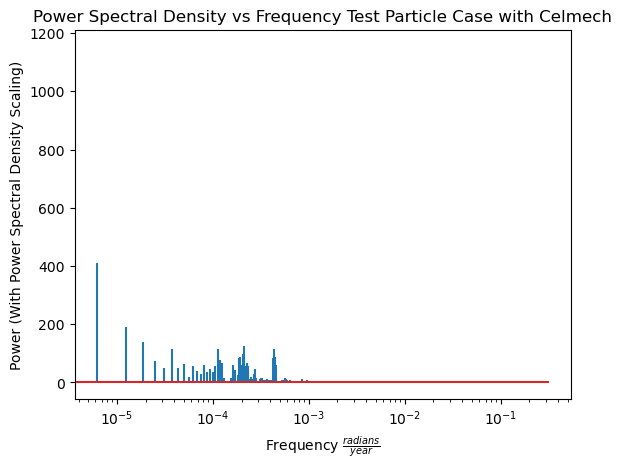

In [36]:
## fourrier transform tests
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=8.87,e=0.04,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

sim.move_to_com()

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
#pham.add_cosine_term([4,-2,-1,-1,0,0,], indexIn = 1, indexOut = 2)
pham.add_cosine_term([4,-2,-2,0,0,0], indexIn = 1, indexOut = 2)
pham.add_cosine_term([4, -2, 0, -2, 0, 0], indexIn = 1, indexOut = 2)
pham.add_cosine_term([2,-1,0,-1,0,0], indexIn = 1, indexOut = 2)
pham.add_cosine_term([2,-1,-1,0,0,0], indexIn = 1, indexOut = 2)
#pham.add_MMR_terms(2,1, indexIn = 1, indexOut = 2, max_order = 2)
pham.add_secular_terms(indexIn = 1, indexOut = 2, max_order = 2)

times, pomega_sat, pomega_jup, e_sat, a_sat, a_jup, lam_sat, lam_j = hk_integrate(pham, 1e6, 1e5)


f,pxx = pomega_ft(times, pomega_sat, e_sat)
plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.title(r'Power Spectral Density vs Frequency Test Particle Case with Celmech')
plt.show()

['Lambda1', 'Lambda2', 'eta1', 'eta2', 'kappa1', 'kappa2', 'lambda1', 'lambda2']
*** Differentiating  ***
-8.880166634820344e-05
*** Starting Simulation ***


100%|████████████████████████████████████████████████████████████████████████| 100000/100000 [00:05<00:00, 16935.03it/s]


-8.880166634819656e-05
Energy Percent Change: 7.752876807837332e-12 %
*** Simulation Complete ***
Time elapsed  = 5.909093098000085 seconds


TypeError: _AxesBase.set_ylim() got an unexpected keyword argument 'y'

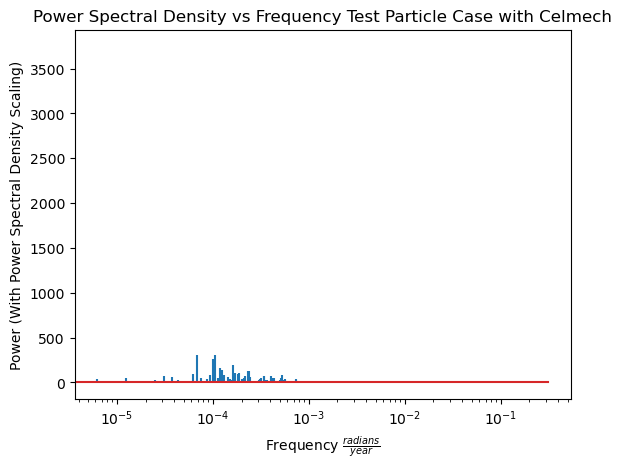

In [37]:
## fourrier transform tests
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=8.87,e=0.04,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

sim.move_to_com()

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_cosine_term([4,-2,-1,-1,0,0,], indexIn = 1, indexOut = 2)
#pham.add_cosine_term([4,-2,-2,0,0,0], indexIn = 1, indexOut = 2)
pham.add_cosine_term([4, -2, 0, -2, 0, 0], indexIn = 1, indexOut = 2)
pham.add_cosine_term([2,-1,0,-1,0,0], indexIn = 1, indexOut = 2)
pham.add_cosine_term([2,-1,-1,0,0,0], indexIn = 1, indexOut = 2)
#pham.add_MMR_terms(2,1, indexIn = 1, indexOut = 2, max_order = 2)
pham.add_secular_terms(indexIn = 1, indexOut = 2, max_order = 2)

times, pomega_sat, pomega_jup, e_sat, a_sat, a_jup, lam_sat, lam_j = hk_integrate(pham, 1e6, 1e5)


f,pxx = pomega_ft(times, pomega_sat, e_sat)
plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.title(r'Power Spectral Density vs Frequency Test Particle Case with Celmech')
plt.ylim(y=500)
plt.show()

['Lambda1', 'Lambda2', 'eta1', 'eta2', 'kappa1', 'kappa2', 'lambda1', 'lambda2']
*** Differentiating  ***
-8.880166634829491e-05
*** Starting Simulation ***


100%|████████████████████████████████████████████████████████████████████████| 100000/100000 [00:05<00:00, 17248.96it/s]


-8.880166634829506e-05
Energy Percent Change: 1.6787725371284018e-13 %
*** Simulation Complete ***
Time elapsed  = 5.800179441000182 seconds


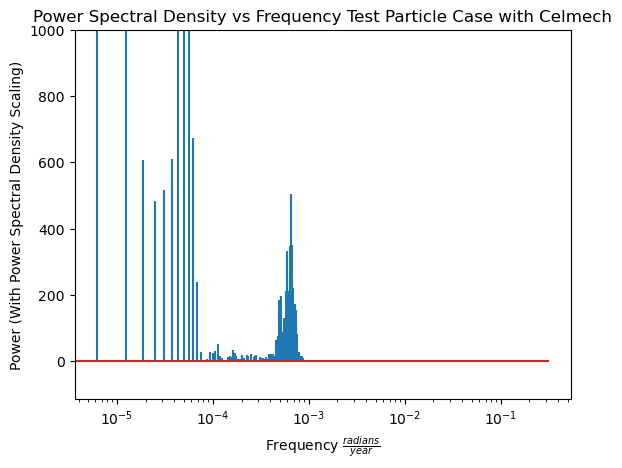

In [28]:
## fourrier transform tests
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=8.87,e=0.04,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

sim.move_to_com()

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_cosine_term([4,-2,-1,-1,0,0,], indexIn = 1, indexOut = 2)
pham.add_cosine_term([4,-2,-2,0,0,0], indexIn = 1, indexOut = 2)
#pham.add_cosine_term([4, -2, 0, -2, 0, 0], indexIn = 1, indexOut = 2)
pham.add_cosine_term([2,-1,0,-1,0,0], indexIn = 1, indexOut = 2)
pham.add_cosine_term([2,-1,-1,0,0,0], indexIn = 1, indexOut = 2)
#pham.add_MMR_terms(2,1, indexIn = 1, indexOut = 2, max_order = 2)
pham.add_secular_terms(indexIn = 1, indexOut = 2, max_order = 2)

times, pomega_sat, pomega_jup, e_sat, a_sat, a_jup, lam_sat, lam_j = hk_integrate(pham, 1e6, 1e5)


f,pxx = pomega_ft(times, pomega_sat, e_sat)
plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.title(r'Power Spectral Density vs Frequency Test Particle Case with Celmech')
plt.ylim(top=1000)
plt.show()

In [ ]:
## fourrier transform tests
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=8.87,e=0.04,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

sim.move_to_com()

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_cosine_term([4,-2,-1,-1,0,0,], indexIn = 1, indexOut = 2)
#pham.add_cosine_term([4,-2,-2,0,0,0], indexIn = 1, indexOut = 2)
#pham.add_cosine_term([4, -2, 0, -2, 0, 0], indexIn = 1, indexOut = 2)
pham.add_cosine_term([2,-1,0,-1,0,0], indexIn = 1, indexOut = 2)
pham.add_cosine_term([2,-1,-1,0,0,0], indexIn = 1, indexOut = 2)
#pham.add_MMR_terms(2,1, indexIn = 1, indexOut = 2, max_order = 2)
pham.add_secular_terms(indexIn = 1, indexOut = 2, max_order = 2)

times, pomega_sat, pomega_jup, e_sat, a_sat, a_jup, lam_sat, lam_j = hk_integrate(pham, 1e6, 1e5)


f,pxx = pomega_ft(times, pomega_sat, e_sat)
plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.title(r'Power Spectral Density vs Frequency Test Particle Case with Celmech')
plt.show()

['Lambda1', 'Lambda2', 'eta1', 'eta2', 'kappa1', 'kappa2', 'lambda1', 'lambda2']
*** Differentiating  ***
-8.88016663481819e-05
*** Starting Simulation ***


100%|████████████████████████████████████████████████████████████████████████| 100000/100000 [00:05<00:00, 16898.59it/s]


-8.880166634818582e-05
Energy Percent Change: 4.410593302097505e-12 %
*** Simulation Complete ***
Time elapsed  = 5.920555861999674 seconds


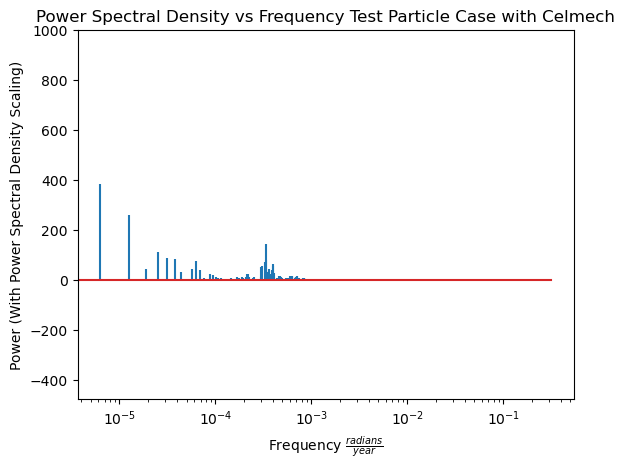

In [30]:
## fourrier transform tests
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=8.87,e=0.04,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

sim.move_to_com()

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_cosine_term([4,-2,-1,-1,0,0,], indexIn = 1, indexOut = 2)
pham.add_cosine_term([4,-2,-2,0,0,0], indexIn = 1, indexOut = 2)
pham.add_cosine_term([4, -2, 0, -2, 0, 0], indexIn = 1, indexOut = 2)
#pham.add_cosine_term([2,-1,0,-1,0,0], indexIn = 1, indexOut = 2)
pham.add_cosine_term([2,-1,-1,0,0,0], indexIn = 1, indexOut = 2)
#pham.add_MMR_terms(2,1, indexIn = 1, indexOut = 2, max_order = 2)
pham.add_secular_terms(indexIn = 1, indexOut = 2, max_order = 2)

times, pomega_sat, pomega_jup, e_sat, a_sat, a_jup, lam_sat, lam_j = hk_integrate(pham, 1e6, 1e5)


f,pxx = pomega_ft(times, pomega_sat, e_sat)
plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.title(r'Power Spectral Density vs Frequency Test Particle Case with Celmech')
plt.ylim(top=1000)
plt.show()

['Lambda1', 'Lambda2', 'eta1', 'eta2', 'kappa1', 'kappa2', 'lambda1', 'lambda2']
*** Differentiating  ***
-8.880166634754562e-05
*** Starting Simulation ***


100%|████████████████████████████████████████████████████████████████████████| 100000/100000 [00:06<00:00, 16056.02it/s]


-8.880166634756009e-05
Energy Percent Change: 1.6299355178802376e-11 %
*** Simulation Complete ***
Time elapsed  = 6.2301973929997985 seconds


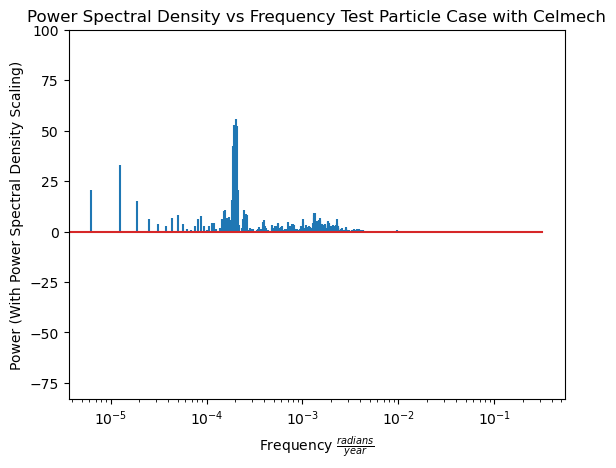

In [38]:
## fourrier transform tests
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=8.87,e=0.04,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

sim.move_to_com()

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_cosine_term([4,-2,-1,-1,0,0,], indexIn = 1, indexOut = 2)
pham.add_cosine_term([4,-2,-2,0,0,0], indexIn = 1, indexOut = 2)
pham.add_cosine_term([4, -2, 0, -2, 0, 0], indexIn = 1, indexOut = 2)
pham.add_cosine_term([2,-1,0,-1,0,0], indexIn = 1, indexOut = 2)
#pham.add_cosine_term([2,-1,-1,0,0,0], indexIn = 1, indexOut = 2)
#pham.add_MMR_terms(2,1, indexIn = 1, indexOut = 2, max_order = 2)
pham.add_secular_terms(indexIn = 1, indexOut = 2, max_order = 2)

times, pomega_sat, pomega_jup, e_sat, a_sat, a_jup, lam_sat, lam_j = hk_integrate(pham, 1e6, 1e5)


f,pxx = pomega_ft(times, pomega_sat, e_sat)
plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.title(r'Power Spectral Density vs Frequency Test Particle Case with Celmech')
plt.ylim(top=100)
plt.show()

['Lambda1', 'Lambda2', 'eta1', 'eta2', 'kappa1', 'kappa2', 'lambda1', 'lambda2']
*** Differentiating  ***
-8.880166634823682e-05
*** Starting Simulation ***


100%|████████████████████████████████████████████████████████████████████████| 100000/100000 [00:06<00:00, 15664.91it/s]


-8.880166634822881e-05
Energy Percent Change: 9.019586994941222e-12 %
*** Simulation Complete ***
Time elapsed  = 6.385828999999831 seconds


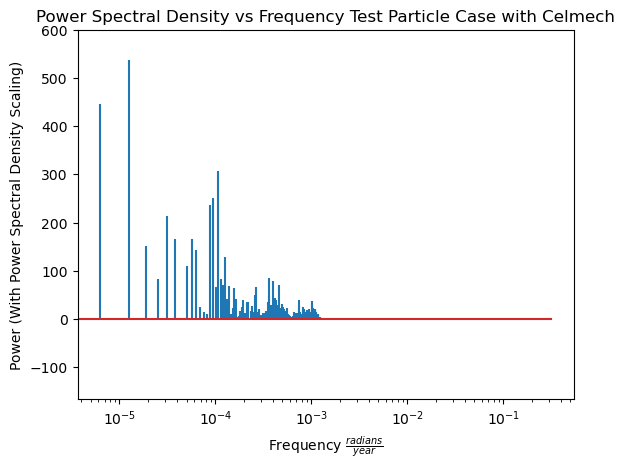

In [39]:
## fourrier transform tests
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=8.87,e=0.04,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

sim.move_to_com()

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_cosine_term([4,-2,-1,-1,0,0,], indexIn = 1, indexOut = 2)
pham.add_cosine_term([4,-2,-2,0,0,0], indexIn = 1, indexOut = 2)
pham.add_cosine_term([4, -2, 0, -2, 0, 0], indexIn = 1, indexOut = 2)
pham.add_cosine_term([2,-1,0,-1,0,0], indexIn = 1, indexOut = 2)
pham.add_cosine_term([2,-1,-1,0,0,0], indexIn = 1, indexOut = 2)
#pham.add_MMR_terms(2,1, indexIn = 1, indexOut = 2, max_order = 2)
pham.add_secular_terms(indexIn = 1, indexOut = 2, max_order = 2)

times, pomega_sat, pomega_jup, e_sat, a_sat, a_jup, lam_sat, lam_j = hk_integrate(pham, 1e6, 1e5)


f,pxx = pomega_ft(times, pomega_sat, e_sat)
plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.title(r'Power Spectral Density vs Frequency Test Particle Case with Celmech')
plt.ylim(top=600)
plt.show()

['Lambda1', 'Lambda2', 'eta1', 'eta2', 'kappa1', 'kappa2', 'lambda1', 'lambda2']
*** Differentiating  ***
-8.880166634823682e-05
*** Starting Simulation ***


100%|████████████████████████████████████████████████████████████████████████| 100000/100000 [00:06<00:00, 16343.80it/s]


-8.880166634822883e-05
Energy Percent Change: 9.004325426421863e-12 %
*** Simulation Complete ***
Time elapsed  = 6.120899406000717 seconds


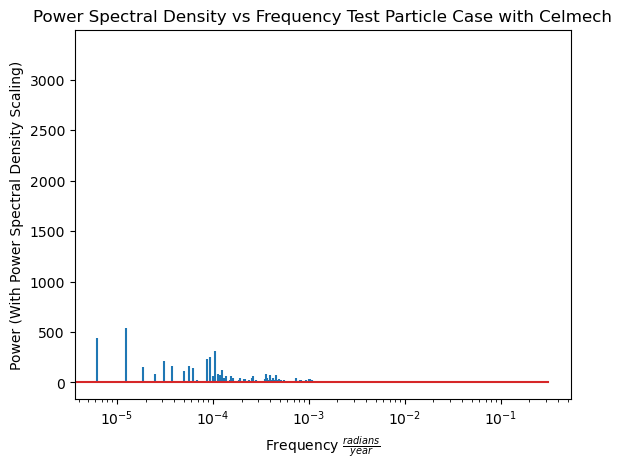

In [33]:
## fourrier transform tests
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=8.87,e=0.04,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

sim.move_to_com()

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_MMR_terms(2,1, indexIn = 1, indexOut = 2, max_order = 2)
pham.add_secular_terms(indexIn = 1, indexOut = 2, max_order = 2)

times, pomega_sat, pomega_jup, e_sat, a_sat, a_jup, lam_sat, lam_j = hk_integrate(pham, 1e6, 1e5)


f,pxx = pomega_ft(times, pomega_sat, e_sat)
plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.title(r'Power Spectral Density vs Frequency Test Particle Case with Celmech')
plt.show()

['Lambda1', 'Lambda2', 'eta1', 'eta2', 'kappa1', 'kappa2', 'lambda1', 'lambda2']
*** Differentiating  ***
-8.880166634824185e-05
*** Starting Simulation ***


100%|█████████████████████████████████████████████████████████████████████████| 100000/100000 [00:13<00:00, 7442.94it/s]


-8.880166634822767e-05
Energy Percent Change: 1.5963600671248704e-11 %
*** Simulation Complete ***
Time elapsed  = 13.438155830000142 seconds


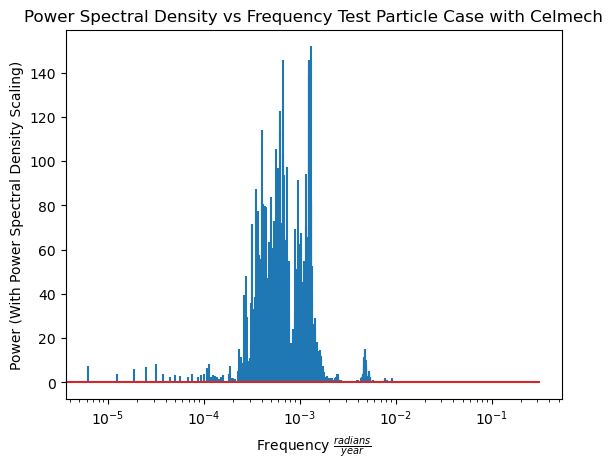

In [34]:
## fourrier transform tests
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=8.87,e=0.04,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

sim.move_to_com()

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_MMR_terms(2,1, indexIn = 1, indexOut = 2, max_order = 3)
pham.add_secular_terms(indexIn = 1, indexOut = 2, max_order = 2)

times, pomega_sat, pomega_jup, e_sat, a_sat, a_jup, lam_sat, lam_j = hk_integrate(pham, 1e6, 1e5)


f,pxx = pomega_ft(times, pomega_sat, e_sat)
plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.title(r'Power Spectral Density vs Frequency Test Particle Case with Celmech')
#plt.ylim(top=1000)
plt.show()

In [40]:
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=8.87,e=0.04,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

sim.move_to_com()

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_MMR_terms(2,1, indexIn = 1, indexOut = 2, max_order = 3)
pham.add_secular_terms(indexIn = 1, indexOut = 2, max_order = 2)

pham.df

<IPython.core.display.Math object>

['Lambda1', 'Lambda2', 'eta1', 'eta2', 'kappa1', 'kappa2', 'lambda1', 'lambda2']
*** Differentiating  ***
-8.88016663482727e-05
*** Starting Simulation ***


100%|████████████████████████████████████████████████████████████████████████| 100000/100000 [00:08<00:00, 12370.03it/s]


-8.88016663482743e-05
Energy Percent Change: 1.8008650852836453e-12 %
*** Simulation Complete ***
Time elapsed  = 8.086705706999055 seconds


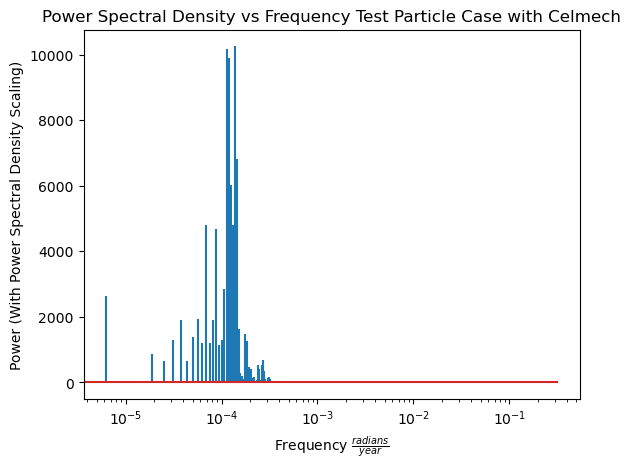

In [71]:
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=8.87,e=0.04,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

sim.move_to_com()

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_cosine_term([4,-2,-1,-1,0,0], indexIn = 1, indexOut = 2)
pham.add_cosine_term([6,-3,-2,-1,0,0], indexIn = 1, indexOut = 2)
pham.add_cosine_term([6,-3,-1,-2,0,0], indexIn = 1, indexOut = 2)
pham.add_cosine_term([2,-1,-1,0,0,0], indexIn = 1, indexOut = 2)
pham.add_cosine_term([2,-1,0,-1,0,0], indexIn = 1, indexOut = 2)
pham.add_secular_terms(indexIn = 1, indexOut = 2, max_order = 2)

times, pomega_sat, pomega_jup, e_sat, a_sat, a_jup, lam_sat, lam_j = hk_integrate(pham, 1e6, 1e5)


f,pxx = pomega_ft(times, pomega_sat, e_sat)
plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.title(r'Power Spectral Density vs Frequency Test Particle Case with Celmech')
plt.show()

['Lambda1', 'Lambda2', 'eta1', 'eta2', 'kappa1', 'kappa2', 'lambda1', 'lambda2']
*** Differentiating  ***
-8.880166634824235e-05
*** Starting Simulation ***


100%|████████████████████████████████████████████████████████████████████████| 100000/100000 [00:09<00:00, 10260.24it/s]


-8.880166634825033e-05
Energy Percent Change: 8.989063857901944e-12 %
*** Simulation Complete ***
Time elapsed  = 9.749110982000275 seconds


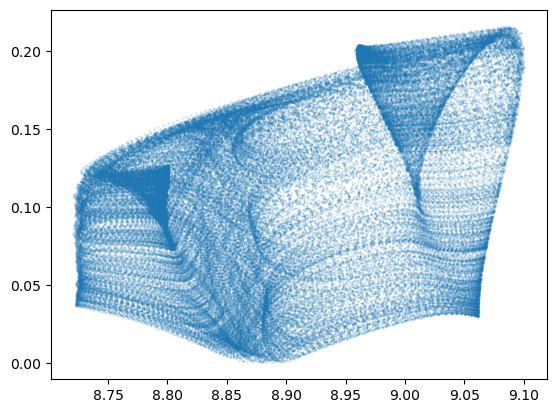

In [56]:
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=8.87,e=0.04,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

sim.move_to_com()

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_cosine_term([4,-2,-1,-1,0,0], indexIn = 1, indexOut = 2)
pham.add_cosine_term([6,-3,-2,-1,0,0], indexIn = 1, indexOut = 2)
pham.add_cosine_term([6,-3,-1,-2,0,0], indexIn = 1, indexOut = 2)
pham.add_cosine_term([4,-2,0,-2,0,0], indexIn = 1, indexOut = 2)
pham.add_cosine_term([4,-2,-2,0,0,0], indexIn = 1, indexOut = 2)
pham.add_cosine_term([6,-3,0,-3,0,0],indexIn = 1, indexOut = 2)
pham.add_cosine_term([6,-3,-3,0,0,0],indexIn = 1, indexOut = 2)
pham.add_MMR_terms(2,1,indexIn = 1, indexOut = 2, max_order = 1)
pham.add_secular_terms(indexIn = 1, indexOut = 2, max_order = 2)

times, pomega_sat, pomega_jup, e_sat, a_sat, a_jup, lam_sat, lam_j = hk_integrate(pham, 1e6, 1e5)

plt.scatter(a_sat, e_sat, s = 0.25, alpha = 0.25)
plt.show()

In [52]:
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=8.87,e=0.04,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

sim.move_to_com()

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_MMR_terms(2,1, indexIn = 1, indexOut = 2, max_order = 3)
pham.add_secular_terms(indexIn = 1, indexOut = 2, max_order = 2)
pham.df

<IPython.core.display.Math object>